In [1]:
# Install libraries (run once)
import subprocess
subprocess.run(['pip', 'install', 'pandas', 'numpy', 'matplotlib', 'seaborn'])

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

Matplotlib is building the font cache; this may take a moment.


✅ All libraries imported successfully!


###  Load the Titanic Dataset

In [2]:
# Load Titanic dataset directly from URL (no download needed)
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print("✅ Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

✅ Dataset loaded successfully!
Shape: 891 rows × 12 columns


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Basic Dataset Info

In [3]:
print("=" * 50)
print("DATASET INFORMATION")
print("=" * 50)
print(df.info())

print("\n" + "=" * 50)
print("BASIC STATISTICS")
print("=" * 50)
df.describe()

DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None

BASIC STATISTICS


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Check Missing Values

MISSING VALUES ANALYSIS
          Missing Count  Missing Percentage
Cabin               687           77.104377
Age                 177           19.865320
Embarked              2            0.224467


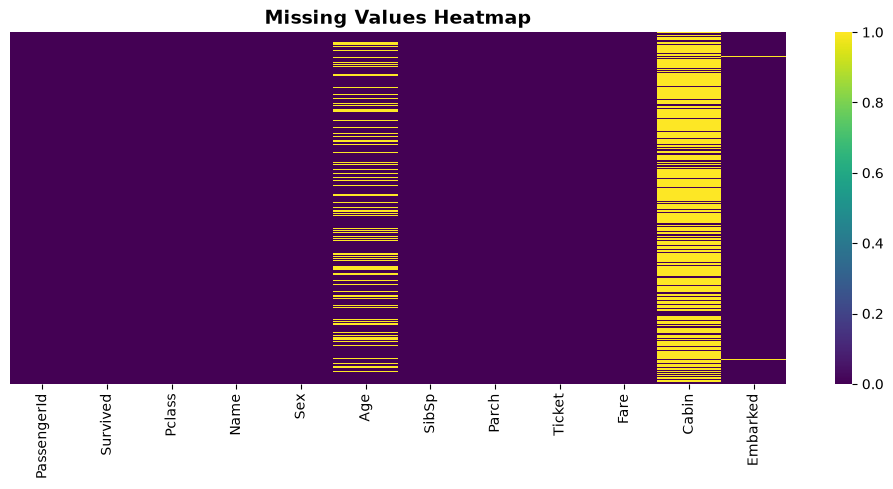

✅ Missing values chart saved!


In [4]:
print("=" * 50)
print("MISSING VALUES ANALYSIS")
print("=" * 50)

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage': missing_pct
}).sort_values('Missing Percentage', ascending=False)

print(missing_df[missing_df['Missing Count'] > 0])

# Visualise missing values
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), 
            yticklabels=False, 
            cbar=True, 
            cmap='viridis')
plt.title('Missing Values Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('missing_values_heatmap.png', dpi=150)
plt.show()
print("✅ Missing values chart saved!")

### Survival Distribution (Pie + Bar)

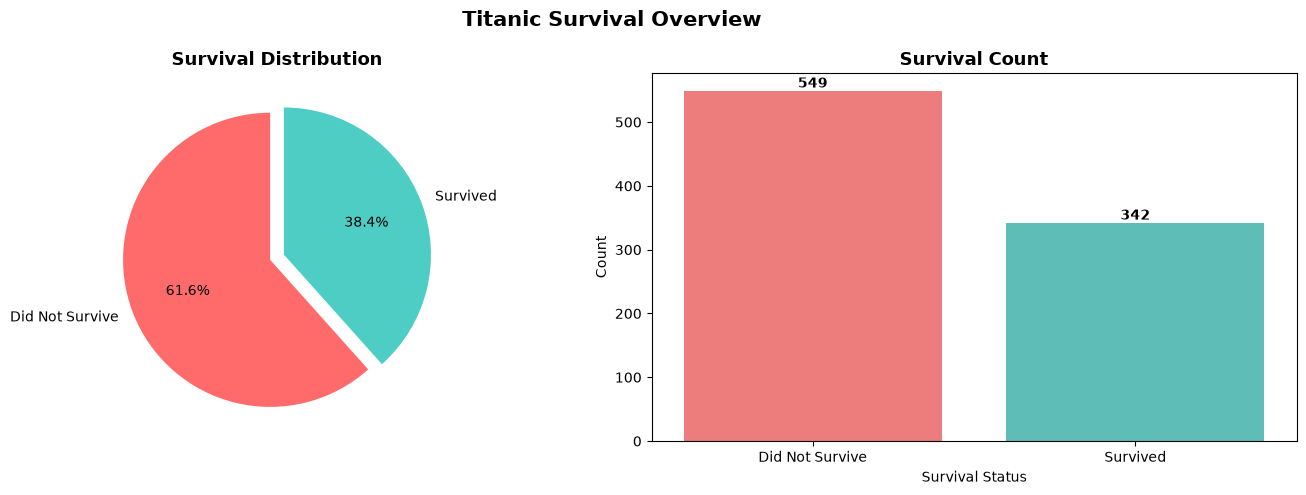

✅ Survival distribution chart saved!


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
survival_counts = df['Survived'].value_counts()
labels = ['Did Not Survive', 'Survived']
colors = ['#FF6B6B', '#4ECDC4']
axes[0].pie(survival_counts, 
            labels=labels, 
            autopct='%1.1f%%',
            colors=colors, 
            startangle=90,
            explode=(0.05, 0.05))
axes[0].set_title('Survival Distribution', fontsize=13, fontweight='bold')

# Bar chart
sns.countplot(data=df, x='Survived', 
              palette=['#FF6B6B', '#4ECDC4'], ax=axes[1])
axes[1].set_xticklabels(['Did Not Survive', 'Survived'])
axes[1].set_title('Survival Count', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Survival Status')
axes[1].set_ylabel('Count')

# Add value labels on bars
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', 
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

plt.suptitle('Titanic Survival Overview', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('survival_distribution.png', dpi=150)
plt.show()
print("✅ Survival distribution chart saved!")

### Survival by Gender

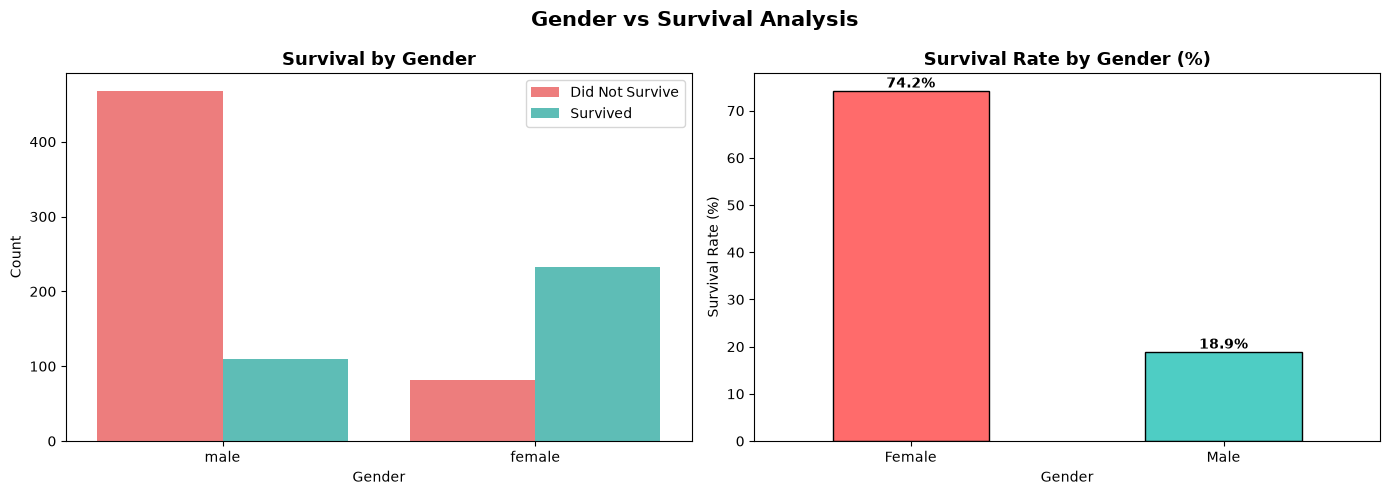


📊 Survival Rates:
Sex
female    74.2%
male      18.9%
Name: Survived, dtype: str


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(data=df, x='Sex', hue='Survived',
              palette=['#FF6B6B', '#4ECDC4'], ax=axes[0])
axes[0].set_title('Survival by Gender', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')
axes[0].legend(['Did Not Survive', 'Survived'])

# Survival rate by gender
survival_rate = df.groupby('Sex')['Survived'].mean() * 100
survival_rate.plot(kind='bar', color=['#FF6B6B','#4ECDC4'],
                   ax=axes[1], edgecolor='black')
axes[1].set_title('Survival Rate by Gender (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_xticklabels(['Female', 'Male'], rotation=0)

for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

plt.suptitle('Gender vs Survival Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('survival_by_gender.png', dpi=150)
plt.show()

print("\n📊 Survival Rates:")
print(df.groupby('Sex')['Survived'].mean().apply(lambda x: f"{x*100:.1f}%"))

### Survival by Passenger Class

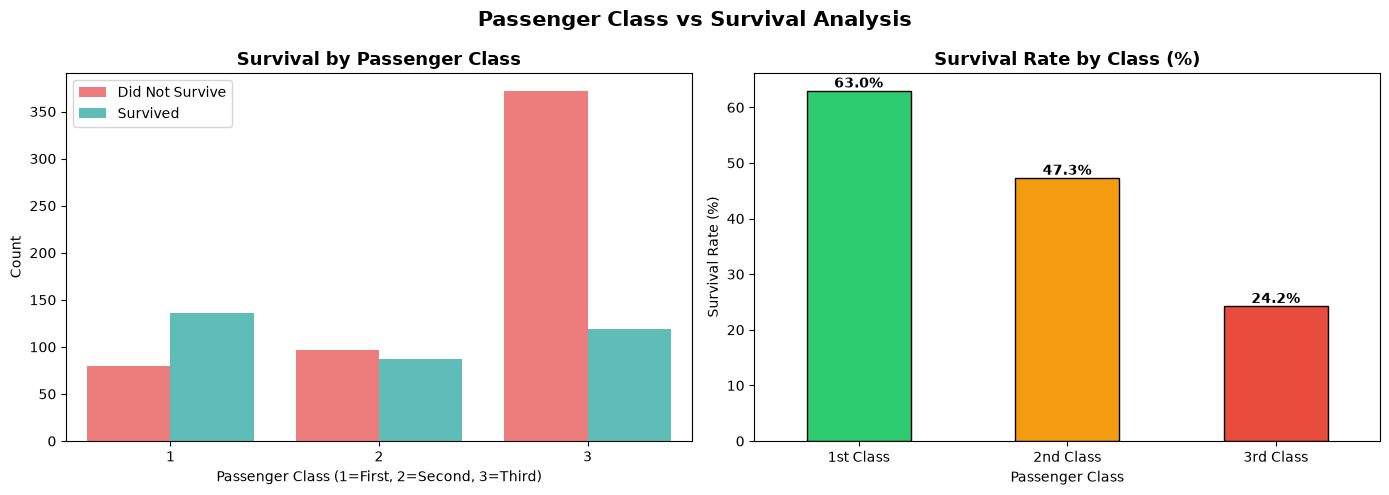

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(data=df, x='Pclass', hue='Survived',
              palette=['#FF6B6B', '#4ECDC4'], ax=axes[0])
axes[0].set_title('Survival by Passenger Class', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Passenger Class (1=First, 2=Second, 3=Third)')
axes[0].set_ylabel('Count')
axes[0].legend(['Did Not Survive', 'Survived'])

# Survival rate by class
survival_by_class = df.groupby('Pclass')['Survived'].mean() * 100
survival_by_class.plot(kind='bar', 
                       color=['#2ECC71', '#F39C12', '#E74C3C'],
                       ax=axes[1], edgecolor='black')
axes[1].set_title('Survival Rate by Class (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Passenger Class')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_xticklabels(['1st Class', '2nd Class', '3rd Class'], rotation=0)

for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

plt.suptitle('Passenger Class vs Survival Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('survival_by_class.png', dpi=150)
plt.show()

### Age Distribution

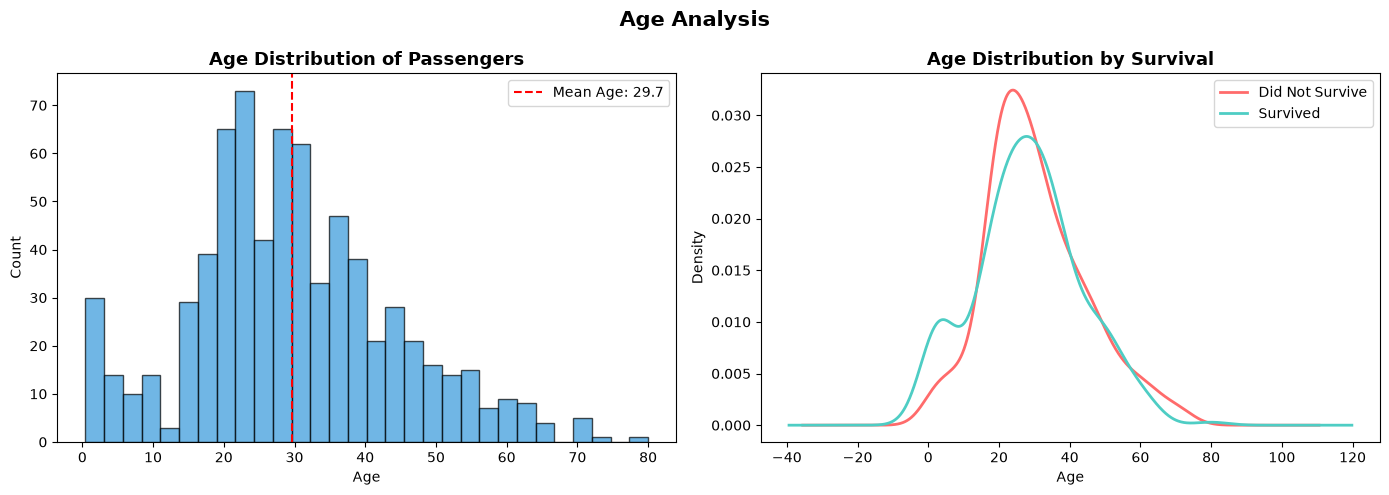


📊 Age Statistics:
Mean Age: 29.7
Youngest: 0.42
Oldest: 80.0
Missing Age values: 177


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age histogram
axes[0].hist(df['Age'].dropna(), bins=30, 
             color='#3498DB', edgecolor='black', alpha=0.7)
axes[0].set_title('Age Distribution of Passengers', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].axvline(df['Age'].mean(), color='red', 
                linestyle='--', label=f'Mean Age: {df["Age"].mean():.1f}')
axes[0].legend()

# Age vs Survival (KDE plot)
df[df['Survived']==0]['Age'].dropna().plot(kind='kde', 
                                            ax=axes[1], 
                                            color='#FF6B6B',
                                            label='Did Not Survive',
                                            linewidth=2)
df[df['Survived']==1]['Age'].dropna().plot(kind='kde', 
                                            ax=axes[1], 
                                            color='#4ECDC4',
                                            label='Survived',
                                            linewidth=2)
axes[1].set_title('Age Distribution by Survival', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.suptitle('Age Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('age_distribution.png', dpi=150)
plt.show()

print(f"\n📊 Age Statistics:")
print(f"Mean Age: {df['Age'].mean():.1f}")
print(f"Youngest: {df['Age'].min()}")
print(f"Oldest: {df['Age'].max()}")
print(f"Missing Age values: {df['Age'].isnull().sum()}")

 ### Fare Distribution & Correlation Heatmap

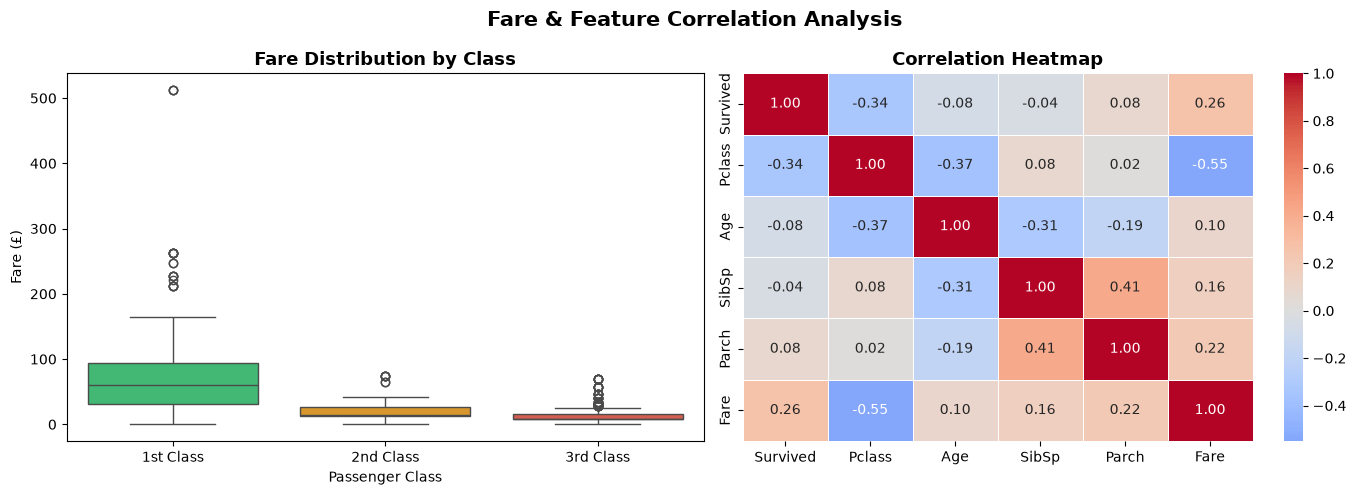

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fare distribution by class
sns.boxplot(data=df, x='Pclass', y='Fare',
            palette=['#2ECC71', '#F39C12', '#E74C3C'], ax=axes[0])
axes[0].set_title('Fare Distribution by Class', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Passenger Class')
axes[0].set_ylabel('Fare (£)')
axes[0].set_xticklabels(['1st Class', '2nd Class', '3rd Class'])

# Correlation heatmap
numeric_cols = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']]
corr_matrix = numeric_cols.corr()
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            ax=axes[1],
            linewidths=0.5)
axes[1].set_title('Correlation Heatmap', fontsize=13, fontweight='bold')

plt.suptitle('Fare & Feature Correlation Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

### Final Summary & Key Insights

In [10]:
print("=" * 60)
print("       TITANIC EDA — KEY INSIGHTS SUMMARY")
print("=" * 60)

total = len(df)
survived = df['Survived'].sum()
female_survival = df[df['Sex']=='female']['Survived'].mean()*100
male_survival = df[df['Sex']=='male']['Survived'].mean()*100
class1_survival = df[df['Pclass']==1]['Survived'].mean()*100
class3_survival = df[df['Pclass']==3]['Survived'].mean()*100

print(f"\n📌 Dataset: {total} passengers, {df.shape[1]} features")
print(f"\n📌 Overall Survival Rate: {survived/total*100:.1f}%")
print(f"   → {survived} survived out of {total} passengers")

print(f"\n📌 Gender Impact:")
print(f"   → Female survival rate: {female_survival:.1f}%")
print(f"   → Male survival rate:   {male_survival:.1f}%")

print(f"\n📌 Class Impact:")
print(f"   → 1st Class survival rate: {class1_survival:.1f}%")
print(f"   → 3rd Class survival rate: {class3_survival:.1f}%")

print(f"\n📌 Age:")
print(f"   → Average age: {df['Age'].mean():.1f} years")
print(f"   → {df['Age'].isnull().sum()} missing age values (20% of data)")

print(f"\n📌 Missing Data:")
print(f"   → Age: {df['Age'].isnull().sum()} missing")
print(f"   → Cabin: {df['Cabin'].isnull().sum()} missing")
print(f"   → Embarked: {df['Embarked'].isnull().sum()} missing")

print("\n" + "=" * 60)
print("✅ EDA Complete! Charts saved as PNG files.")
print("=" * 60)

       TITANIC EDA — KEY INSIGHTS SUMMARY

📌 Dataset: 891 passengers, 12 features

📌 Overall Survival Rate: 38.4%
   → 342 survived out of 891 passengers

📌 Gender Impact:
   → Female survival rate: 74.2%
   → Male survival rate:   18.9%

📌 Class Impact:
   → 1st Class survival rate: 63.0%
   → 3rd Class survival rate: 24.2%

📌 Age:
   → Average age: 29.7 years
   → 177 missing age values (20% of data)

📌 Missing Data:
   → Age: 177 missing
   → Cabin: 687 missing
   → Embarked: 2 missing

✅ EDA Complete! Charts saved as PNG files.
